In [44]:
import pandas as pd
import os 
import glob

In [45]:
raw_data_path = r"data\raw"
csv_files= glob.glob(os.path.join(raw_data_path, "*.csv"))
print(f"found {len(csv_files)} csv files")
for f in csv_files:
    print(f" - {os.path.basename(f)}")

found 8 csv files
 - Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
 - Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
 - Friday-WorkingHours-Morning.pcap_ISCX.csv
 - Monday-WorkingHours.pcap_ISCX.csv
 - Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
 - Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
 - Tuesday-WorkingHours.pcap_ISCX.csv
 - Wednesday-workingHours.pcap_ISCX.csv


In [46]:
dataframes=[]
for f in csv_files:
    df=pd.read_csv(f)
    print(f"{os.path.basename(f)}: { df.shape[0]} rows, {df.shape[1]} columns")
    dataframes.append(df)

Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv: 225745 rows, 79 columns
Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv: 286467 rows, 79 columns
Friday-WorkingHours-Morning.pcap_ISCX.csv: 191033 rows, 79 columns
Monday-WorkingHours.pcap_ISCX.csv: 529918 rows, 79 columns
Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv: 288602 rows, 79 columns
Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv: 170366 rows, 79 columns
Tuesday-WorkingHours.pcap_ISCX.csv: 445909 rows, 79 columns
Wednesday-workingHours.pcap_ISCX.csv: 692703 rows, 79 columns


In [47]:
combined_df =pd.concat(dataframes, ignore_index=True)
print(f"combined dataframe: {combined_df.shape}")

combined dataframe: (2830743, 79)


In [48]:
print(combined_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2830743 entries, 0 to 2830742
Data columns (total 79 columns):
 #   Column                        Dtype  
---  ------                        -----  
 0    Destination Port             int64  
 1    Flow Duration                int64  
 2    Total Fwd Packets            int64  
 3    Total Backward Packets       int64  
 4   Total Length of Fwd Packets   int64  
 5    Total Length of Bwd Packets  int64  
 6    Fwd Packet Length Max        int64  
 7    Fwd Packet Length Min        int64  
 8    Fwd Packet Length Mean       float64
 9    Fwd Packet Length Std        float64
 10  Bwd Packet Length Max         int64  
 11   Bwd Packet Length Min        int64  
 12   Bwd Packet Length Mean       float64
 13   Bwd Packet Length Std        float64
 14  Flow Bytes/s                  float64
 15   Flow Packets/s               float64
 16   Flow IAT Mean                float64
 17   Flow IAT Std                 float64
 18   Flow IAT Max         

In [49]:
print(combined_df.isnull().sum().sum())

1358


In [50]:
output_path =r"data\combined_dataset.csv"
os.makedirs(os.path.dirname(output_path), exist_ok=True)
combined_df.to_csv(output_path , index=False)
print(f"combined dataset saved top {output_path}")

KeyboardInterrupt: 

In [51]:
combined_df.describe()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
count,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,...,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06
mean,8.071483e+03,1.478566e+07,9.361160e+00,1.039377e+01,5.493024e+02,1.616264e+04,2.075999e+02,1.871366e+01,5.820194e+01,6.891013e+01,...,5.418218e+00,-2.741688e+03,8.155132e+04,4.113412e+04,1.531825e+05,5.829582e+04,8.316037e+06,5.038439e+05,8.695752e+06,7.920031e+06
std,1.828363e+04,3.365374e+07,7.496728e+02,9.973883e+02,9.993589e+03,2.263088e+06,7.171848e+02,6.033935e+01,1.860912e+02,2.811871e+02,...,6.364257e+02,1.084989e+06,6.485999e+05,3.933815e+05,1.025825e+06,5.770923e+05,2.363008e+07,4.602984e+06,2.436689e+07,2.336342e+07
min,0.000000e+00,-1.300000e+01,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,-5.368707e+08,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,5.300000e+01,1.550000e+02,2.000000e+00,1.000000e+00,1.200000e+01,0.000000e+00,6.000000e+00,0.000000e+00,6.000000e+00,0.000000e+00,...,0.000000e+00,2.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,8.000000e+01,3.131600e+04,2.000000e+00,2.000000e+00,6.200000e+01,1.230000e+02,3.700000e+01,2.000000e+00,3.400000e+01,0.000000e+00,...,1.000000e+00,2.400000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,4.430000e+02,3.204828e+06,5.000000e+00,4.000000e+00,1.870000e+02,4.820000e+02,8.100000e+01,3.600000e+01,5.000000e+01,2.616295e+01,...,2.000000e+00,3.200000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,6.553500e+04,1.200000e+08,2.197590e+05,2.919220e+05,1.290000e+07,6.554530e+08,2.482000e+04,2.325000e+03,5.940857e+03,7.125597e+03,...,2.135570e+05,1.380000e+02,1.100000e+08,7.420000e+07,1.100000e+08,1.100000e+08,1.200000e+08,7.690000e+07,1.200000e+08,1.200000e+08


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
2830738,53,32215,4,2,112,152,28,28,28.0,0.00000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2830739,53,324,2,2,84,362,42,42,42.0,0.00000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2830740,58030,82,2,1,31,6,31,0,15.5,21.92031,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2830741,53,1048635,6,2,192,256,32,32,32.0,0.00000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2830742,53,94939,4,2,188,226,47,47,47.0,0.00000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [ ]:
print(combined_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2830743 entries, 0 to 2830742
Data columns (total 79 columns):
 #   Column                        Dtype  
---  ------                        -----  
 0    Destination Port             int64  
 1    Flow Duration                int64  
 2    Total Fwd Packets            int64  
 3    Total Backward Packets       int64  
 4   Total Length of Fwd Packets   int64  
 5    Total Length of Bwd Packets  int64  
 6    Fwd Packet Length Max        int64  
 7    Fwd Packet Length Min        int64  
 8    Fwd Packet Length Mean       float64
 9    Fwd Packet Length Std        float64
 10  Bwd Packet Length Max         int64  
 11   Bwd Packet Length Min        int64  
 12   Bwd Packet Length Mean       float64
 13   Bwd Packet Length Std        float64
 14  Flow Bytes/s                  float64
 15   Flow Packets/s               float64
 16   Flow IAT Mean                float64
 17   Flow IAT Std                 float64
 18   Flow IAT Max         

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns  
numeric_cols =combined_df.select_dtypes(include='number')
corr_matrix = numeric_cols.corr()

In [ ]:
corr_matrix


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
Destination Port,1.000000,-0.151680,-0.004236,-0.003947,0.011145,-0.003082,0.097926,-0.045388,0.140220,0.128861,...,-0.003226,0.000897,-0.035562,-0.043717,-0.051859,-0.023194,-0.112585,0.010399,-0.108185,-0.114614
Flow Duration,-0.151680,1.000000,0.020857,0.019670,0.065456,0.016186,0.273308,-0.105230,0.143689,0.234437,...,0.015942,-0.001357,0.189299,0.241060,0.294034,0.121171,0.768034,0.243154,0.779527,0.738328
Total Fwd Packets,-0.004236,0.020857,1.000000,0.999070,0.365508,0.996993,0.009358,-0.002989,0.000032,0.001403,...,0.887387,-0.000184,0.039937,0.008329,0.030459,0.041283,0.001820,0.000809,0.001906,0.001670
Total Backward Packets,-0.003947,0.019670,0.999070,1.000000,0.359451,0.994429,0.009039,-0.002600,-0.000333,0.001026,...,0.882566,0.000018,0.038963,0.006437,0.028602,0.041278,0.001425,0.000492,0.001456,0.001330
Total Length of Fwd Packets,0.011145,0.065456,0.365508,0.359451,1.000000,0.353762,0.197030,-0.000275,0.185262,0.159787,...,0.407448,-0.001209,0.101084,0.103326,0.126493,0.068325,0.022660,0.027064,0.026079,0.018634
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Active Min,-0.023194,0.121171,0.041283,0.041278,0.068325,0.039069,0.105641,-0.025912,0.081170,0.094164,...,0.031394,-0.006834,0.905862,0.033874,0.584503,1.000000,0.118133,0.038302,0.122651,0.112880
Idle Mean,-0.112585,0.768034,0.001820,0.001425,0.022660,0.000809,0.181135,-0.071304,0.127959,0.183139,...,0.000837,-0.000876,0.120171,0.036551,0.088904,0.118133,1.000000,0.150248,0.990387,0.990215
Idle Std,0.010399,0.243154,0.000809,0.000492,0.027064,0.000105,0.178091,-0.029951,0.178462,0.191278,...,0.000721,-0.003720,0.070586,0.081435,0.070002,0.038302,0.150248,1.000000,0.283330,0.011609
Idle Max,-0.108185,0.779527,0.001906,0.001456,0.026079,0.000797,0.199559,-0.073419,0.148402,0.203304,...,0.000929,-0.001407,0.132700,0.055300,0.102816,0.122651,0.990387,0.283330,1.000000,0.961812


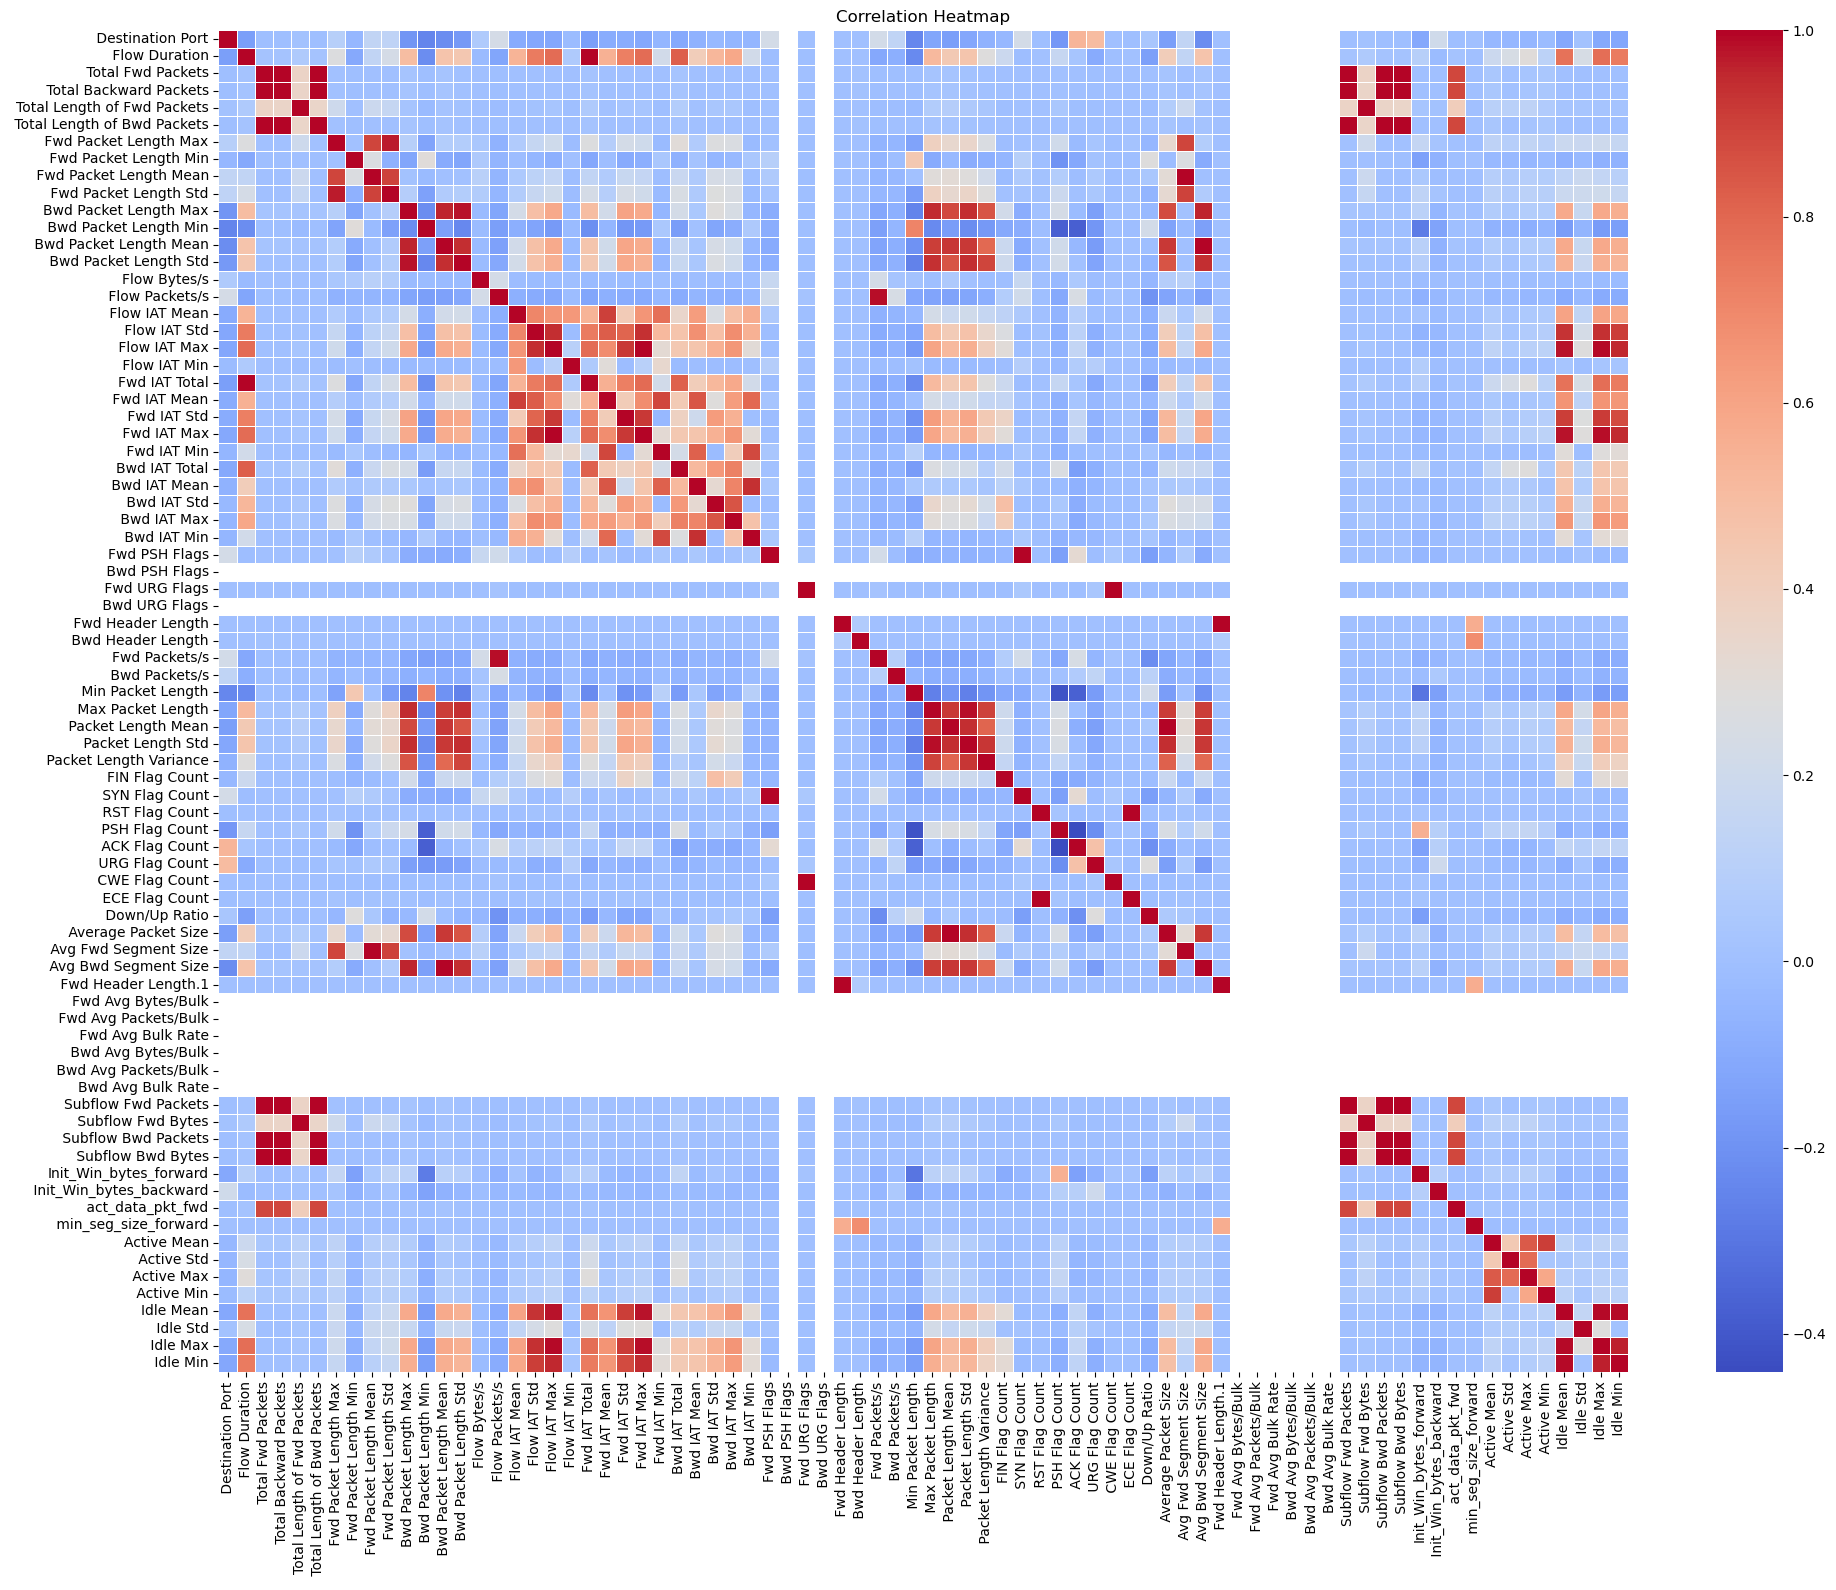

In [53]:
plt.figure(figsize=(20,16))
sns.heatmap(corr_matrix , annot= False , cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [54]:
threshold = 0.9

# Get upper triangle to avoid duplicates
upper_tri = corr_matrix.where(
    pd.np.triu(pd.np.ones(corr_matrix.shape), k=1).astype(bool)
    if hasattr(pd, 'np') else
    __import__('numpy').triu(__import__('numpy').ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr_pairs = [
    (col, row, upper_tri.loc[row, col])
    for col in upper_tri.columns
    for row in upper_tri.index
    if abs(upper_tri.loc[row, col]) >= threshold
]

high_corr_df = pd.DataFrame(high_corr_pairs, columns=["Feature 1", "Feature 2", "Correlation"])
high_corr_df = high_corr_df.sort_values(by="Correlation", ascending=False).reset_index(drop=True)

print(f"Found {len(high_corr_df)} feature pairs with |correlation| >= {threshold}:\n")
high_corr_df

Found 71 feature pairs with |correlation| >= 0.9:



,Feature 1,Feature 2,Correlation
0,Fwd Header Length.1,Fwd Header Length,1.000000
1,Subflow Bwd Packets,Total Backward Packets,1.000000
2,Subflow Fwd Packets,Total Fwd Packets,1.000000
3,CWE Flag Count,Fwd URG Flags,1.000000
4,SYN Flag Count,Fwd PSH Flags,1.000000
...,...,...,...
66,Active Min,Active Mean,0.905862
67,Max Packet Length,Bwd Packet Length Mean,0.905434
68,Avg Bwd Segment Size,Max Packet Length,0.905434
69,Idle Mean,Fwd IAT Std,0.904528


In [56]:
import numpy as np

# Identify columns to drop (one from each highly correlated pair)
threshold = 0.9
corr_matrix_abs = numeric_cols.corr().abs()
upper = corr_matrix_abs.where(np.triu(np.ones(corr_matrix_abs.shape), k=1).astype(bool))

cols_to_drop = [col for col in upper.columns if any(upper[col] >= threshold)]
print(f"Dropping {len(cols_to_drop)} highly correlated columns:")
for c in cols_to_drop:
    print(f"  - {c}")

combined_df_reduced = combined_df.drop(columns=cols_to_drop)
print(f"\nShape before: {combined_df.shape}")
print(f"Shape after:  {combined_df_reduced.shape}")

Dropping 31 highly correlated columns:
  -  Total Backward Packets
  -  Total Length of Bwd Packets
  -  Fwd Packet Length Std
  -  Bwd Packet Length Mean
  -  Bwd Packet Length Std
  -  Flow IAT Max
  - Fwd IAT Total
  -  Fwd IAT Mean
  -  Fwd IAT Std
  -  Fwd IAT Max
  -  Bwd IAT Min
  - Fwd Packets/s
  -  Max Packet Length
  -  Packet Length Mean
  -  Packet Length Std
  -  Packet Length Variance
  -  SYN Flag Count
  -  CWE Flag Count
  -  ECE Flag Count
  -  Average Packet Size
  -  Avg Fwd Segment Size
  -  Avg Bwd Segment Size
  -  Fwd Header Length.1
  - Subflow Fwd Packets
  -  Subflow Fwd Bytes
  -  Subflow Bwd Packets
  -  Subflow Bwd Bytes
  -  Active Min
  - Idle Mean
  -  Idle Max
  -  Idle Min

Shape before: (2830743, 79)
Shape after:  (2830743, 48)


Target column: ' Label'

 Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64


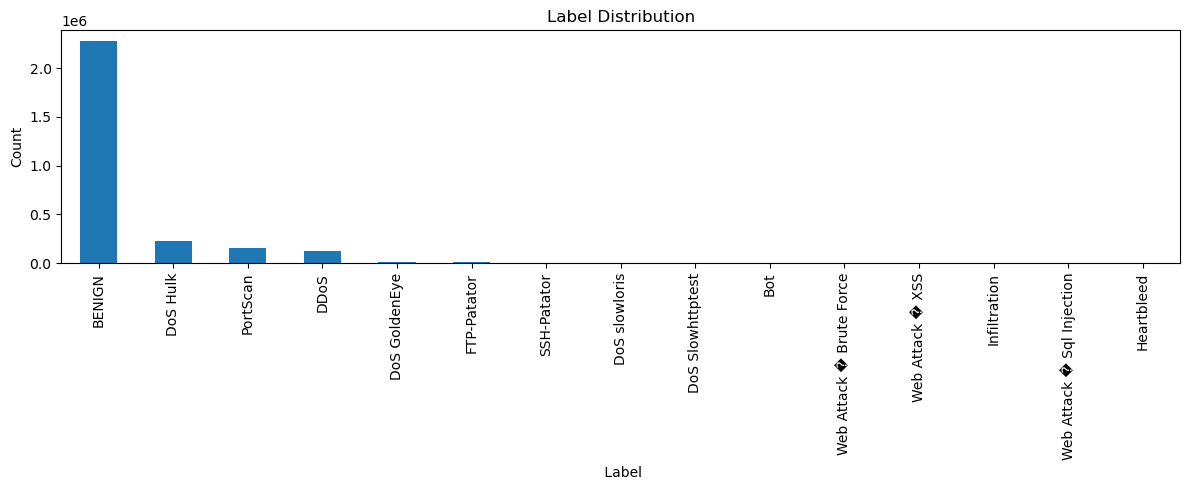

In [57]:
# Update 'Label' to your actual target column name
target_col = combined_df_reduced.columns[-1]  # assumes last column is label
print(f"Target column: '{target_col}'\n")
print(combined_df_reduced[target_col].value_counts())
combined_df_reduced[target_col].value_counts().plot(kind='bar', figsize=(12, 5), title="Label Distribution")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [58]:
# Replace infinities with NaN, then drop rows with NaN
combined_df_reduced.replace([np.inf, -np.inf], np.nan, inplace=True)
print(f"Missing values: {combined_df_reduced.isnull().sum().sum()}")

combined_df_cleaned = combined_df_reduced.dropna()
print(f"Shape after cleaning: {combined_df_cleaned.shape}")

Missing values: 5734
Shape after cleaning: (2827876, 48)


In [59]:
clean_output_path = r"data\cleaned_dataset.csv"
combined_df_cleaned.to_csv(clean_output_path, index=False)
print(f"Cleaned dataset saved to: {clean_output_path}")

Cleaned dataset saved to: data\cleaned_dataset.csv


C:\Users\dsgau\AppData\Local\Temp\ipykernel_19776\748075187.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_df_cleaned[target_col] = combined_df_cleaned[target_col].str.strip()
C:\Users\dsgau\AppData\Local\Temp\ipykernel_19776\748075187.py:39: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_df_cleaned['Label_Grouped'] = combined_df_cleaned[target_col].apply(map_label)


Grouped Label Distribution:

Label_Grouped
Benign          2271320
DoS              379737
PortScan         158804
Brute Force       13832
Web Attack         2180
Bot                1956
Infiltration         36
Heartbleed           11
Name: count, dtype: int64


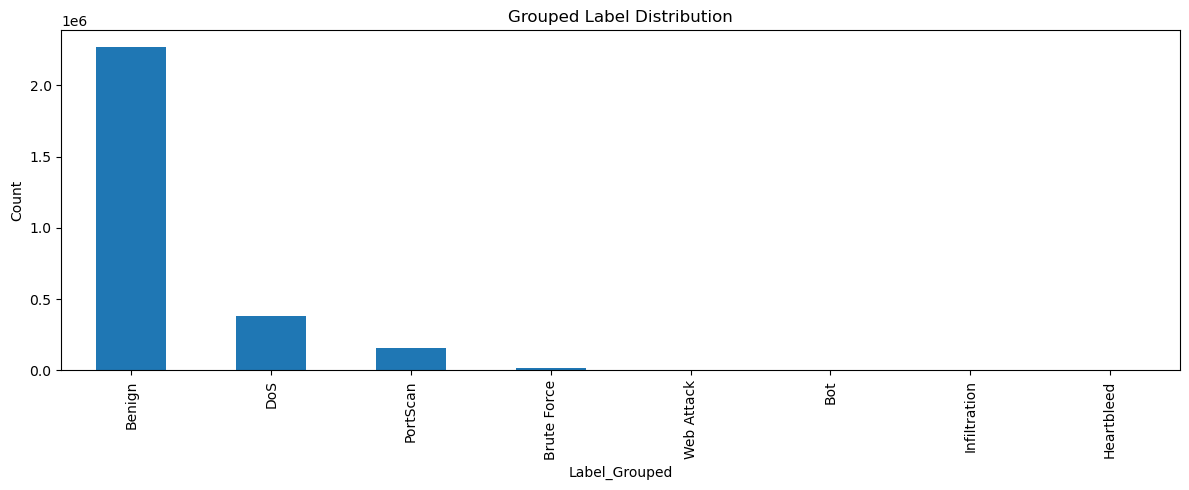

In [60]:
import re

target_col = combined_df_cleaned.columns[-1]
combined_df_cleaned[target_col] = combined_df_cleaned[target_col].str.strip()

def map_label(label):
    label = label.strip()
    
    if re.match(r'^BENIGN$', label, re.IGNORECASE):
        return 'Benign'
    
    elif re.search(r'DoS', label, re.IGNORECASE):
        return 'DoS'
    
    elif re.search(r'DDoS', label, re.IGNORECASE):
        return 'DDoS'
    
    elif re.search(r'Patator|Brute\s*Force', label, re.IGNORECASE) and not re.search(r'Web', label, re.IGNORECASE):
        return 'Brute Force'
    
    elif re.search(r'Web\s*Attack', label, re.IGNORECASE):
        return 'Web Attack'
    
    elif re.search(r'PortScan', label, re.IGNORECASE):
        return 'PortScan'
    
    elif re.search(r'Bot', label, re.IGNORECASE):
        return 'Bot'
    
    elif re.search(r'Infiltration', label, re.IGNORECASE):
        return 'Infiltration'
    
    elif re.search(r'Heartbleed', label, re.IGNORECASE):
        return 'Heartbleed'
    
    else:
        return label  # keep original if no match

combined_df_cleaned['Label_Grouped'] = combined_df_cleaned[target_col].apply(map_label)

print("Grouped Label Distribution:\n")
print(combined_df_cleaned['Label_Grouped'].value_counts())

combined_df_cleaned['Label_Grouped'].value_counts().plot(kind='bar', figsize=(12, 5), title="Grouped Label Distribution")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [61]:
# Check if any labels were NOT matched (still original)
unmapped = combined_df_cleaned[combined_df_cleaned[target_col] != combined_df_cleaned['Label_Grouped']]
still_original = combined_df_cleaned[combined_df_cleaned[target_col] == combined_df_cleaned['Label_Grouped']]
if len(still_original) > 0:
    print(f"Unmapped labels:\n{still_original[target_col].value_counts()}")
else:
    print("All labels successfully mapped!")

# Drop old label, rename grouped
combined_df_cleaned.drop(columns=[target_col], inplace=True)
combined_df_cleaned.rename(columns={'Label_Grouped': 'Label'}, inplace=True)

print(f"\nFinal shape: {combined_df_cleaned.shape}")
print(f"\nFinal Label Distribution:\n{combined_df_cleaned['Label'].value_counts()}")

Unmapped labels:
 Label
PortScan        158804
Bot               1956
Infiltration        36
Heartbleed          11
Name: count, dtype: int64

Final shape: (2827876, 48)

Final Label Distribution:
Label
Benign          2271320
DoS              379737
PortScan         158804
Brute Force       13832
Web Attack         2180
Bot                1956
Infiltration         36
Heartbleed           11
Name: count, dtype: int64


C:\Users\dsgau\AppData\Local\Temp\ipykernel_19776\1543018506.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_df_cleaned.drop(columns=[target_col], inplace=True)
C:\Users\dsgau\AppData\Local\Temp\ipykernel_19776\1543018506.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_df_cleaned.rename(columns={'Label_Grouped': 'Label'}, inplace=True)


In [2]:
import re

# Use .copy() to avoid SettingWithCopyWarning
combined_df_cleaned = combined_df_reduced.replace([np.inf, -np.inf], np.nan).dropna().copy()

target_col = combined_df_cleaned.columns[-1]
combined_df_cleaned[target_col] = combined_df_cleaned[target_col].str.strip()

def map_label(label):
    label = label.strip()
    
    if re.match(r'^BENIGN$', label, re.IGNORECASE):
        return 'Benign'
    
    # DDoS MUST come before DoS (otherwise DoS catches DDoS too)
    elif re.search(r'DDoS', label, re.IGNORECASE):
        return 'DDoS'
    
    elif re.search(r'DoS', label, re.IGNORECASE):
        return 'DoS'
    
    elif re.search(r'Patator|Brute\s*Force', label, re.IGNORECASE) and not re.search(r'Web', label, re.IGNORECASE):
        return 'Brute Force'
    
    elif re.search(r'Web\s*Attack', label, re.IGNORECASE):
        return 'Web Attack'
    
    elif re.search(r'Port\s*Scan', label, re.IGNORECASE):
        return 'PortScan'
    
    elif re.search(r'Bot', label, re.IGNORECASE):
        return 'Bot'
    
    elif re.search(r'Infiltration', label, re.IGNORECASE):
        return 'Infiltration'
    
    elif re.search(r'Heartbleed', label, re.IGNORECASE):
        return 'Heartbleed'
    
    else:
        return label

combined_df_cleaned['Label_Grouped'] = combined_df_cleaned[target_col].apply(map_label)

print("Grouped Label Distribution:\n")
print(combined_df_cleaned['Label_Grouped'].value_counts())

combined_df_cleaned['Label_Grouped'].value_counts().plot(kind='bar', figsize=(12, 5), title="Grouped Label Distribution")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

NameError: name 'combined_df_reduced' is not defined

In [63]:
# Verify all labels are mapped
still_original = combined_df_cleaned[combined_df_cleaned[target_col] == combined_df_cleaned['Label_Grouped']]
if len(still_original) > 0:
    print(f"Unmapped labels:\n{still_original[target_col].value_counts()}")
else:
    print("All labels successfully mapped!")

# Drop old label, rename grouped (no warning with .copy())
combined_df_cleaned = combined_df_cleaned.drop(columns=[target_col])
combined_df_cleaned = combined_df_cleaned.rename(columns={'Label_Grouped': 'Label'})

print(f"\nFinal shape: {combined_df_cleaned.shape}")
print(f"\nFinal Label Distribution:\n{combined_df_cleaned['Label'].value_counts()}")

Unmapped labels:
 Label
PortScan        158804
DDoS            128025
Bot               1956
Infiltration        36
Heartbleed          11
Name: count, dtype: int64

Final shape: (2827876, 48)

Final Label Distribution:
Label
Benign          2271320
DoS              251712
PortScan         158804
DDoS             128025
Brute Force       13832
Web Attack         2180
Bot                1956
Infiltration         36
Heartbleed           11
Name: count, dtype: int64


In [5]:
import re

# Use .copy() to avoid SettingWithCopyWarning
combined_df_cleaned = combined_df_reduced.replace([np.inf, -np.inf], np.nan).dropna().copy()

# Strip whitespace from ALL column names
combined_df_cleaned.columns = combined_df_cleaned.columns.str.strip()

target_col = combined_df_cleaned.columns[-1]
combined_df_cleaned[target_col] = combined_df_cleaned[target_col].str.strip()

def map_label(label):
    label = label.strip()
    
    if re.match(r'^BENIGN$', label, re.IGNORECASE):
        return 'Benign'
    
    # DDoS MUST come before DoS (otherwise DoS catches DDoS too)
    elif re.search(r'DDoS', label, re.IGNORECASE):
        return 'DDoS'
    
    elif re.search(r'DoS', label, re.IGNORECASE):
        return 'DoS'
    
    elif re.search(r'Patator|Brute\s*Force', label, re.IGNORECASE) and not re.search(r'Web', label, re.IGNORECASE):
        return 'Brute Force'
    
    elif re.search(r'Web\s*Attack', label, re.IGNORECASE):
        return 'Web Attack'
    
    elif re.search(r'Port\s*Scan', label, re.IGNORECASE):
        return 'PortScan'
    
    elif re.search(r'Bot', label, re.IGNORECASE):
        return 'Bot'
    
    elif re.search(r'Infiltration', label, re.IGNORECASE):
        return 'Infiltration'
    
    elif re.search(r'Heartbleed', label, re.IGNORECASE):
        return 'Heartbleed'
    
    else:
        return label

combined_df_cleaned['Label_Grouped'] = combined_df_cleaned[target_col].apply(map_label)

print("Grouped Label Distribution:\n")
print(combined_df_cleaned['Label_Grouped'].value_counts())

combined_df_cleaned['Label_Grouped'].value_counts().plot(kind='bar', figsize=(12, 5), title="Grouped Label Distribution")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

NameError: name 'combined_df_reduced' is not defined

In [66]:
# Verify all labels are mapped
unique_mapped = combined_df_cleaned['Label_Grouped'].unique()
print(f"Mapped categories: {sorted(unique_mapped)}")

expected_labels = {'Benign', 'DoS', 'DDoS', 'Brute Force', 'Web Attack', 'PortScan', 'Bot', 'Infiltration', 'Heartbleed'}
truly_unmapped = set(unique_mapped) - expected_labels

if truly_unmapped:
    print(f"\n⚠️ Truly unmapped labels: {truly_unmapped}")
else:
    print("\n✅ All labels successfully mapped!")

# Drop old label, rename grouped
combined_df_cleaned = combined_df_cleaned.drop(columns=[target_col])
combined_df_cleaned = combined_df_cleaned.rename(columns={'Label_Grouped': 'Label'})

print(f"\nFinal shape: {combined_df_cleaned.shape}")
print(f"\nFinal Label Distribution:\n{combined_df_cleaned['Label'].value_counts()}")

Mapped categories: ['Benign', 'Bot', 'Brute Force', 'DDoS', 'DoS', 'Heartbleed', 'Infiltration', 'PortScan', 'Web Attack']

✅ All labels successfully mapped!

Final shape: (2827876, 48)

Final Label Distribution:
Label
Benign          2271320
DoS              251712
PortScan         158804
DDoS             128025
Brute Force       13832
Web Attack         2180
Bot                1956
Infiltration         36
Heartbleed           11
Name: count, dtype: int64


In [1]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
combined_df_cleaned['Label_Encoded'] = le.fit_transform(combined_df_cleaned['Label'])

print("Label Encoding Mapping:")
for i, cls in enumerate(le.classes_):
    print(f"  {cls} → {i}")

print(f"\n{combined_df_cleaned['Label_Encoded'].value_counts()}")

NameError: name 'combined_df_cleaned' is not defined